In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np
import time

from itertools import product
import qutip as qt

import h5py
from datetime import datetime
import sys
import os
import shutil
import importlib

sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_simulations")

sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1")
sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements")
sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_simulations")


import current_measurements.src.src_current_measurement_simulations
importlib.reload(current_measurements.src.src_current_measurement_simulations);
from current_measurements.src.src_current_measurement_simulations import CurrentMeasurementSimulation

import current_measurements.src.src_current_measurement_simulations_particle_sector
importlib.reload(current_measurements.src.src_current_measurement_simulations_particle_sector);
from current_measurements.src.src_current_measurement_simulations_particle_sector import CurrentMeasurementSimulationParticleSector

import current_simulations.quantum_states
importlib.reload(current_simulations.quantum_states)
from current_simulations.quantum_states import QuantumState, FockBasisState, FockBasisOuter, DensityMatrix

import quantum_states
importlib.reload(quantum_states)
from quantum_states import QuantumState, FockBasisState, FockBasisOuter, DensityMatrix

import current_simulations.current_simulation
importlib.reload(current_simulations.current_simulation)
from current_simulations.current_simulation import CurrentSimulation



In [11]:
def convert_particle_sector_to_reduced_density_matrix(psi_4particle, 
                                                      basis_4particle, 
                                                      reduced_qubit_indices, 
                                                      num_qubits=8,
                                                      num_levels=5):
    """
    More efficient version that groups states by their traced configurations
    Handles both state vectors and density matrices as input.

    after reducing to reduced density matrix, truncate to remove states that have more than 4 particles in total
    """
    from collections import defaultdict
    
    # Check if input is a density matrix or state vector
    if hasattr(psi_4particle, 'shape') and len(psi_4particle.shape) == 2:
        # Input is a density matrix
        is_density_matrix = True
        if hasattr(psi_4particle, 'full'):
            rho_input = psi_4particle.full()  # QuTiP Qobj
        else:
            rho_input = psi_4particle  # numpy array
    else:
        # Input is a state vector
        is_density_matrix = False
        if hasattr(psi_4particle, 'full'):
            psi_input = psi_4particle.full().flatten()  # QuTiP Qobj
        else:
            psi_input = psi_4particle.flatten()  # numpy array
    

    if psi_4particle.isket:
        is_density_matrix = False
        psi_input = psi_4particle.full().flatten()

    elif psi_4particle.isoper:
        is_density_matrix = True
        rho_input = psi_4particle.full()



    traced_qubits = [i for i in range(num_qubits) if i not in reduced_qubit_indices]
    
    # Group states by (reduced_config, traced_config)
    state_groups = defaultdict(list)
    
    for i, full_state in enumerate(basis_4particle):
        reduced_part = tuple(full_state[j] for j in reduced_qubit_indices)
        traced_part = tuple(full_state[j] for j in traced_qubits)
        state_groups[(reduced_part, traced_part)].append(i)
    
    # Generate basis for reduced qubits
    reduced_basis = list(product(range(num_levels), repeat=len(reduced_qubit_indices)))
    dim_reduced = len(reduced_basis)
    rho_reduced = np.zeros((dim_reduced, dim_reduced), dtype=complex)
    
    # Build density matrix
    for alpha, reduced_alpha in enumerate(reduced_basis):
        for beta, reduced_beta in enumerate(reduced_basis):
            
            matrix_element = 0.0
            
            # Sum over all traced configurations
            all_traced_configs = set()
            for (red_part, traced_part), indices in state_groups.items():
                if red_part == reduced_alpha or red_part == reduced_beta:
                    all_traced_configs.add(traced_part)
            
            for traced_config in all_traced_configs:
                indices_alpha = state_groups.get((reduced_alpha, traced_config), [])
                indices_beta = state_groups.get((reduced_beta, traced_config), [])
                
                if is_density_matrix:
                    # For density matrix input: Tr_traced[rho] = sum over traced indices
                    for i in indices_alpha:
                        for j in indices_beta:
                            matrix_element += rho_input[i, j]
                else:
                    # For state vector input: |psi><psi| -> sum coefficients
                    coeff_alpha = sum(psi_input[i] for i in indices_alpha)
                    coeff_beta = sum(psi_input[i] for i in indices_beta)
                    matrix_element += coeff_alpha * np.conj(coeff_beta)

            rho_reduced[alpha, beta] = matrix_element

    
    basis_4Q_reduced_indices = np.where([sum(state) <= 4 for state in reduced_basis])[0]
    rho_reduced = rho_reduced[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    
    return qt.Qobj(rho_reduced, dims=[[len(basis_4Q_reduced_indices)], [len(basis_4Q_reduced_indices)]])

In [12]:
config_filename = 'current_correlations_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)

# coupling_point = 'coupling_point_2'
eigenstate = 'highest'
# eigenstate = 'lowest'

dephasing = 'no_dephasing'

# for coupling point 1, still need to do these
# coupling_point = 'coupling_point_1'
# dephasing = 0.8
# dephasing = 1.0
# dephasing = 2.0
# dephasing = 5.0
# dephasing = 10.0
# dephasing = 50.0 

# for coupling point 2, still need to do these
# coupling_point = 'coupling_point_2'
# dephasing  = 'no_dephasing_ramp'
# dephasing = 50.0 
# dephasing = 'no_dephasing'

# for coupling point 3, still need to do these
# coupling_point = 'coupling_point_3'
# dephasing = 0.8
# dephasing = 1.0
# dephasing = 2.0
# dephasing = 5.0
# dephasing = 10.0
# dephasing = 50.0 

# for coupling point 4, still need to do these
# coupling_point = 'coupling_point_4'
# dephasing = 'no_dephasing'
# dephasing = 0.001
# dephasing = 0.01
# dephasing = 0.1
# dephasing = 0.2
# dephasing = 0.3
# dephasing = 0.5
# dephasing = 0.8
# dephasing = 1.0
# dephasing = 2.0
# dephasing = 5.0
# dephasing = 10.0
# dephasing = 50.0 


# for coupling point 5, still need to do these
coupling_point = 'coupling_point_5'
# dephasing = 'no_dephasing'
dephasing = 'real'
# dephasing = 0.001
# dephasing = 0.01
# dephasing = 0.1
# dephasing = 0.2
# dephasing = 0.3
# dephasing = 0.5
# dephasing = 0.8
# dephasing = 1.0
# dephasing = 2.0
# dephasing = 5.0
# dephasing = 10.0
# dephasing = 50.0 


coupling_point = 'coupling_point_6'
dephasing = 'real'




coupling_point_config = config[coupling_point]


In [13]:


correlation_pairs = []
for i in range(1, 8):
    for j in range(i + 2, 8):
        correlation_pairs.append(((i, i+1), (j,j+1)))



In [14]:
correlation_pair_to_simulation = {}


In [15]:
### extract simulation data

simulation_config = coupling_point_config['simulation_config']

num_levels = simulation_config['num_levels']
num_qubits = simulation_config['num_qubits']
num_particles = simulation_config['num_particles']

U = simulation_config['U'] * 2  *np.pi
times = np.linspace(simulation_config['time_start'], simulation_config['time_stop'], simulation_config['time_num_points'])

J = []
J_parallel = []

if eigenstate == 'lowest':
    psi0 = -70
else:
    psi0 = simulation_config['psi0']

T1 = simulation_config['T1']
T2 = simulation_config['T2']

coupling_dict = coupling_point_config['coupling']

for i in range(num_qubits-1):
    J_key = f'J_{i+1}{i+2}'
    J_parallel_key = f'J_{i+1}{i+3}'

    if J_key in coupling_dict:
        J.append(coupling_dict[J_key])

    if J_parallel_key in coupling_dict:
        J_parallel.append(coupling_dict[J_parallel_key])

if not len(J) == num_qubits - 1:
    raise ValueError(f'coupling strengths J not properly specified in config file. Needs all pairs J_<i><i+1>. Given length: {len(J)}')

if not len(J_parallel) == num_qubits - 2:
    raise ValueError(f'coupling strengths J_parallel not properly specified in config file. Needs all pairs J_<i><i+2>. Given length: {len(J_parallel)}')

J = np.array(J)*2*np.pi
J_parallel = np.array(J_parallel)*2*np.pi



In [16]:
### load ramp dephasing state data

ramp_state_filename = '../ramp_dephasing_simulations/ramp_dephasing_states.h5'

# Load the full file structure
ramp_state_data = load_nested_dict_from_hdf5(ramp_state_filename)

print(ramp_state_data[coupling_point][eigenstate].keys())



dict_keys(['no_dephasing_ramp', 'real'])


In [17]:
# create initial state from diagonalizing the particle sector Hamiltonian

simulation = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J_parallel, U, times,
                                                       [1,2], [3,4], psi0=psi0, T1=T1, T2=T2)

if isinstance(dephasing, str) and 'no_dephasing' in dephasing:
    if dephasing == 'no_dephasing_ramp':
        print(f'found state for no dephasing ramp')
        psi0_state = qt.Qobj(ramp_state_data[coupling_point][eigenstate]['no_dephasing_ramp'])
        # convert state vecto to density matrix
        psi0_state = psi0_state * psi0_state.dag()
        simulation.psi0 = psi0_state
else:
    T2_sim = str(dephasing)
    if T2_sim in ramp_state_data[coupling_point][eigenstate]:
        print(f'found state for dephasing T2 = {T2_sim}')
        psi0_state = qt.Qobj(ramp_state_data[coupling_point][eigenstate][T2_sim])
        simulation.psi0 = psi0_state
    else:
        raise KeyError

psi0_state = simulation.psi0

basis = list(product(range(num_levels), repeat=num_qubits))
basis_4Q = [state for state in basis if sum(state) == num_particles]


if psi0_state.isoper:
    print(f'purity: {(psi0_state*psi0_state).tr()}')
else:
    print('state vector: purity = 1')

psi0_state

processing psi0, given type: <class 'int'>
found state for dephasing T2 = real
purity: 0.43152738559153847


Quantum object: dims=[[330], [330]], shape=(330, 330), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 3.15724950e-09+4.13304954e-23j -5.58288313e-08-4.44516879e-09j
   2.69207903e-08+1.03483102e-08j ...  8.76158490e-09-1.07437462e-09j
  -1.54092140e-08-2.47638456e-09j  5.06633047e-10-1.19661968e-11j]
 [-5.58288313e-08+4.44516879e-09j  1.76455421e-06+3.50356360e-21j
  -1.17032426e-06-3.25675007e-07j ... -2.47030731e-07+7.63742974e-08j
   4.76454936e-07-9.67431431e-09j -1.45268119e-08+3.00475129e-09j]
 [ 2.69207903e-08-1.03483102e-08j -1.17032426e-06+3.25675007e-07j
   5.78442340e-06-8.27098702e-20j ... -1.20668607e-07-2.48194426e-07j
   5.05804480e-08+4.83200771e-07j -6.05168750e-09-1.39047017e-08j]
 ...
 [ 8.76158490e-09+1.07437462e-09j -2.47030731e-07-7.63742974e-08j
  -1.20668607e-07+2.48194426e-07j ...  7.78162118e-07+2.38279977e-20j
  -9.74097799e-07-1.54208546e-07j  4.74171010e-08+2.02758751e-09j]
 [-1.54092140e-08+2.47638456e-09j  4.76454936e-07+9.67431431e-09j
   5.0580448

In [18]:
def calculate_current_correlation_simulation(annihilation_operators, number_operators, initial_state, 
                                             J, J_parallel, U, measurement_detuning, readout_pair_1, readout_pair_2,
                                             capped=True):
    # Initialize timing
    start_time = time.time()
    last_time = start_time

    H_BS_reduced = 0

    q1, q2 = readout_pair_1
    q3, q4 = readout_pair_2
    qubit_indices = [q1, q2, q3, q4]

    print(f'creating Hamiltonian, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    for i in range(len(number_operators)):
        a_i = annihilation_operators[i]
        q_i = qubit_indices[i]
        for j in range(i+1, len(number_operators)):
            q_j = qubit_indices[j]
            a_j = annihilation_operators[j]
            coupling = 0
            if abs(q_i - q_j) == 1:
                coupling = J[min(q_i, q_j)]

            if abs(q_i - q_j) == 2:
                coupling = J_parallel[min(q_i, q_j)]

            H_BS_reduced += coupling*(a_i.dag()*a_j + a_j.dag()*a_i)

        H_BS_reduced += U/2 * a_i.dag()*a_i*(a_i.dag()*a_i - 1)

        H_BS_reduced += a_i.dag()*a_i*measurement_detuning[q_i]

    reduced_basis = list(product(range(num_levels), repeat=4))
    basis_4Q_reduced_indices = np.where([sum(state) <= 4 for state in reduced_basis])[0]

    
    print(f'Hamiltonian dims: {H_BS_reduced.dims}')

    # truncate Hamiltonian to states with 4 or fewer particles
    # H_BS_reduced = H_BS_reduced[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]

    # H_BS_reduced = qt.Qobj(H_BS_reduced, dims=(len(basis_4Q_reduced_indices), len(basis_4Q_reduced_indices)))


    print(f'running simulation, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    result = qt.mesolve(H_BS_reduced, initial_state, times)

    print(f'calculating populations, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    populations = np.zeros((4, len(times)))

    for i in range(len(number_operators)):
        populations[i,:] = qt.expect(number_operators[i], result.states)

    print(f'calculating covariances, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    covariances = np.zeros((len(number_operators), len(number_operators), len(times)))

    number_operators_measurement = number_operators

    if capped:
        number_operators_capped = [qt.Qobj(np.clip(n.full(), 0, 1), dims=n.dims) for n in number_operators]
        # print(np.diag(number_operators_capped[0].full()))
        number_operators_measurement = number_operators_capped

    for i in range(len(number_operators_measurement)):
        for j in range(len(number_operators_measurement)):
            covariances[i,j,:] = qt.expect(number_operators_measurement[i] * number_operators_measurement[j], result.states)

    covariance_sum = 0

    covariance_sum += covariances[0,2,:] - populations[0, :] * populations[2, :]
    covariance_sum -= covariances[0,3,:] - populations[0, :] * populations[3, :]
    covariance_sum -= covariances[1,2,:] - populations[1, :] * populations[2, :]
    covariance_sum += covariances[1,3,:] - populations[1, :] * populations[3, :]

    # Calculate total function time
    total_function_time = time.time() - start_time
    print(f'done calculating current correlations, time elapsed: {time.time() - last_time:.3f}s, total function time: {total_function_time:.3f}s')

    return covariance_sum

In [19]:
### initialiaze reduced operators in 4Q subspace

a = qt.destroy(num_levels)

a_1 = qt.tensor([a, qt.qeye(num_levels), qt.qeye(num_levels), qt.qeye(num_levels)])
a_2 = qt.tensor([qt.qeye(num_levels), a, qt.qeye(num_levels), qt.qeye(num_levels)])
a_3 = qt.tensor([qt.qeye(num_levels), qt.qeye(num_levels), a, qt.qeye(num_levels)])
a_4 = qt.tensor([qt.qeye(num_levels), qt.qeye(num_levels), qt.qeye(num_levels), a])

annihilation_operators_reduced = [a_1, a_2, a_3, a_4]
number_operators_reduced = [a_i.dag()*a_i for a_i in annihilation_operators_reduced]

# truncated reduced operators to 4 or fewer particles

reduced_basis = list(product(range(num_levels), repeat=4))
basis_4Q_reduced_indices = np.where([sum(state) <= 4 for state in reduced_basis])[0]

annihilation_operators_reduced_truncated = []


for i in range(len(annihilation_operators_reduced)):
    a_i = annihilation_operators_reduced[i]
    a_i_truncated = a_i[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    annihilation_operators_reduced_truncated.append(qt.Qobj(a_i_truncated, dims=(len(basis_4Q_reduced_indices), len(basis_4Q_reduced_indices))))

number_operators_reduced_truncated = []

for i in range(len(number_operators_reduced)):
    n_i = number_operators_reduced[i]
    n_i_truncated = n_i[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    number_operators_reduced_truncated.append(qt.Qobj(n_i_truncated, dims=(len(basis_4Q_reduced_indices), len(basis_4Q_reduced_indices))))

In [20]:
correlation_pair_to_beamsplitter_time = {}
correlation_pair_to_current_correlation = {}
correlation_pair_to_current_correlation_value = {}

In [21]:
for correlation_pair in correlation_pairs:
    # Initialize timing for this iteration
    iteration_start_time = time.time()
    last_time = iteration_start_time

    
    # config_pair_dict = coupling_point_config[str(correlation_pair)]

    readout_qubits_1, readout_qubits_2 = correlation_pair
    
    readout_pair_1 = [q - 1 for q in readout_qubits_1]
    readout_pair_2 = [q - 1 for q in readout_qubits_2]

    if not correlation_pair in correlation_pair_to_current_correlation:

        print(f'correlation pair: {correlation_pair}, time elapsed: {time.time() - last_time:.3f}s')
        last_time = time.time()

        measurement_detuning = coupling_point_config['data_config'][str(correlation_pair)]['measurement_detunings']

        # simulation beamsplitter time is not the same as the measured beamsplitter time
        average_J = 1/2*(abs(J[min(readout_pair_1)]) + abs(J[min(readout_pair_2)])) # MHz
        beamsplitter_time_simulation = np.pi/(4*average_J) # in mus

        correlation_pair_to_beamsplitter_time[correlation_pair] = beamsplitter_time_simulation

        # print(f'beamsplitter_time_simulation: {beamsplitter_time_simulation*1e3} ns')

        print(f'reducing density matrix for qubits: {readout_pair_1 + readout_pair_2}, time elapsed: {time.time() - last_time:.3f}s')
        last_time = time.time()

        rho_reduced_truncated = convert_particle_sector_to_reduced_density_matrix(psi0_state, 
                                                  basis_4Q, 
                                                  readout_pair_1 + readout_pair_2, 
                                                  num_qubits=num_qubits,
                                                  num_levels=num_levels)
        
        # rho_reduced = psi0_state.ptrace(readout_pair_1 + readout_pair_2)
        

        print(f'rho reduced truncated dims: {rho_reduced_truncated.dims}')

        print(f'calculating current correlation, time elapsed: {time.time() - last_time:.3f}s')
        last_time = time.time()

        current_correlation = calculate_current_correlation_simulation(annihilation_operators_reduced_truncated, number_operators_reduced_truncated, rho_reduced_truncated, 
                                             J, J_parallel, U, measurement_detuning, readout_pair_1, readout_pair_2, capped=True)

        current_correlation *= abs(J[min(readout_pair_1)]/2/np.pi) * abs(J[min(readout_pair_2)]/2/np.pi)

        correlation_pair_to_current_correlation[correlation_pair] = current_correlation

        beamsplitter_index = np.argmin(np.abs(times - beamsplitter_time_simulation))
        current_correlation_value = current_correlation[beamsplitter_index]

        correlation_pair_to_current_correlation_value[correlation_pair] = current_correlation_value

        # Calculate total iteration time
        total_iteration_time = time.time() - iteration_start_time
        print(f'done with correlation pair: {correlation_pair}, time elapsed: {time.time() - last_time:.3f}s, ')
        print(f'total iteration time: {total_iteration_time:.3f}s')
        print()

correlation pair: ((1, 2), (3, 4)), time elapsed: 0.000s
reducing density matrix for qubits: [0, 1, 2, 3], time elapsed: 0.000s
rho reduced truncated dims: [[70], [70]]
calculating current correlation, time elapsed: 6.599s
creating Hamiltonian, time elapsed: 0.000s
Hamiltonian dims: [[70], [70]]
running simulation, time elapsed: 0.020s
calculating populations, time elapsed: 146.801s
calculating covariances, time elapsed: 0.000s
done calculating current correlations, time elapsed: 0.066s, total function time: 146.886s
done with correlation pair: ((1, 2), (3, 4)), time elapsed: 146.889s, 
total iteration time: 153.488s

correlation pair: ((1, 2), (4, 5)), time elapsed: 0.000s
reducing density matrix for qubits: [0, 1, 3, 4], time elapsed: 0.000s
rho reduced truncated dims: [[70], [70]]
calculating current correlation, time elapsed: 6.817s
creating Hamiltonian, time elapsed: 0.000s
Hamiltonian dims: [[70], [70]]
running simulation, time elapsed: 0.002s
calculating populations, time elapse

In [22]:
# for correlation_pair in correlation_pairs:
     

#     correlation_pair_to_current_correlation[correlation_pair] /= (2*np.pi)**2


#     correlation_pair_to_current_correlation_value[correlation_pair] /= (2*np.pi)**2

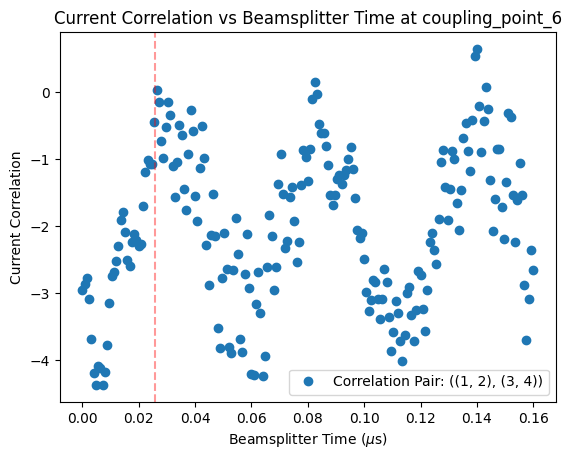

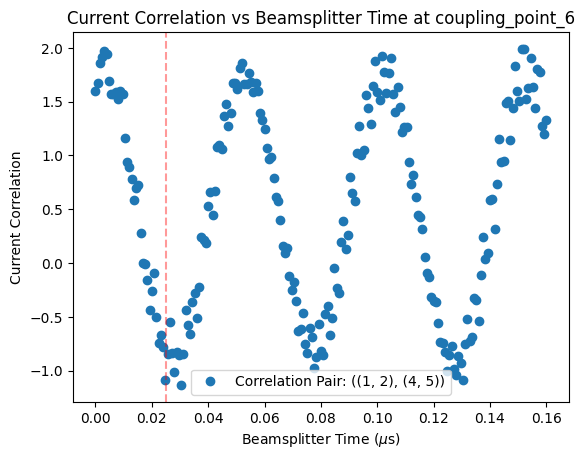

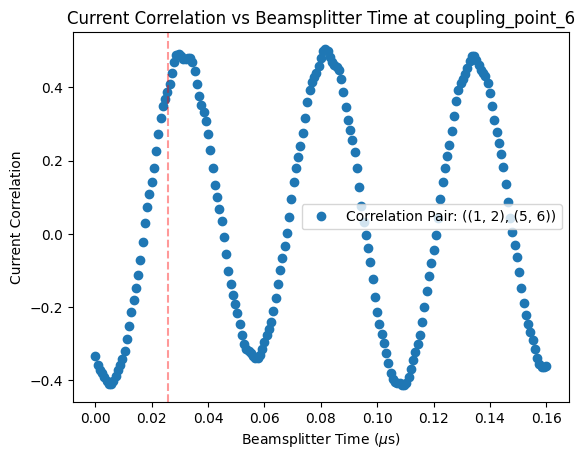

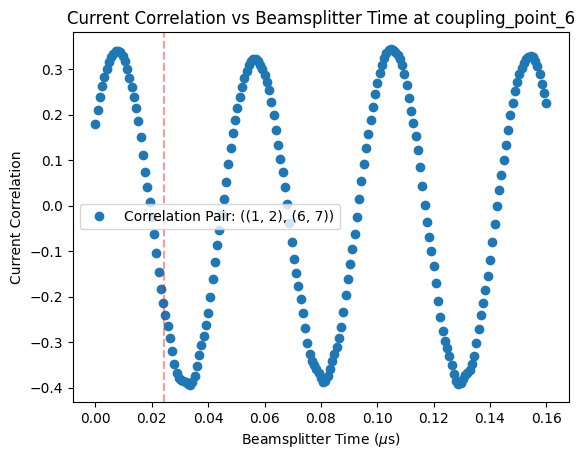

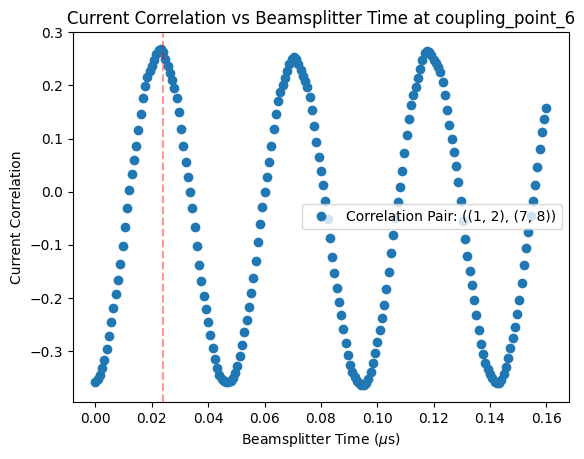

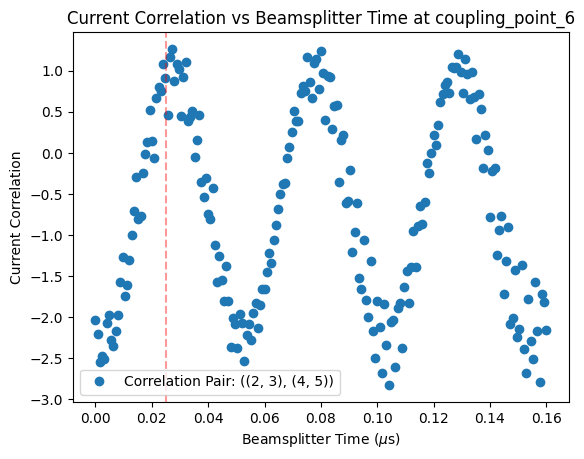

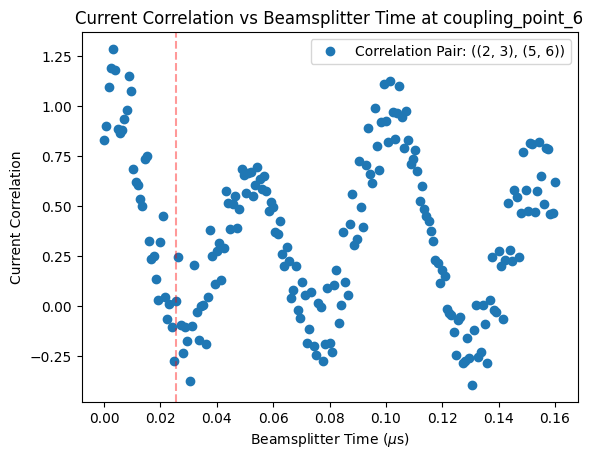

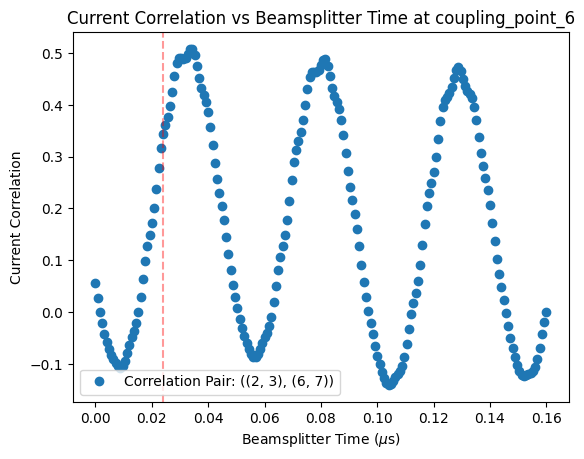

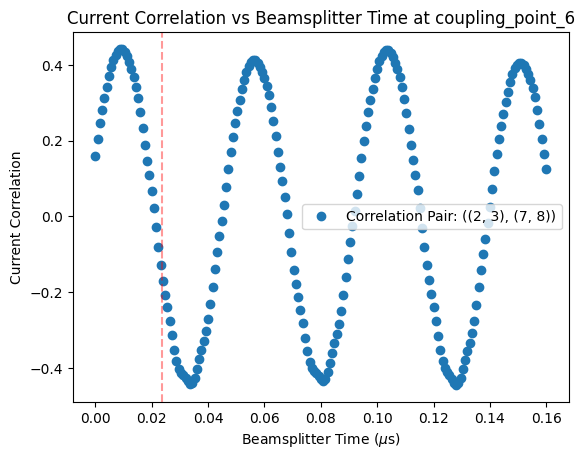

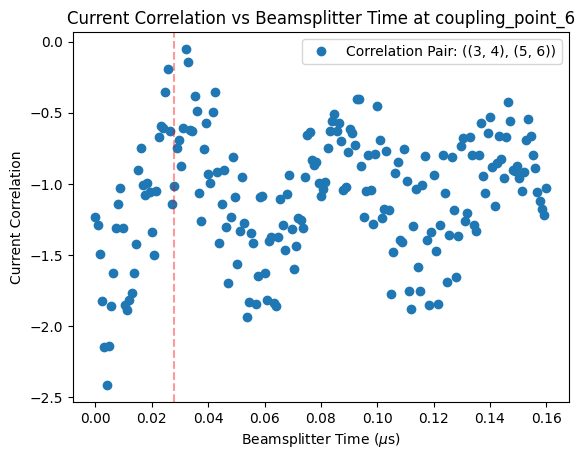

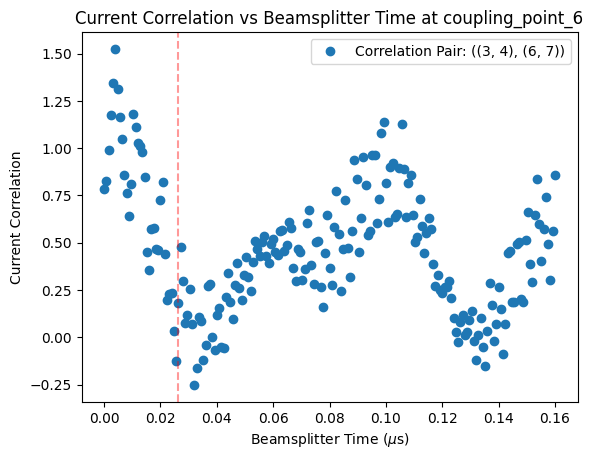

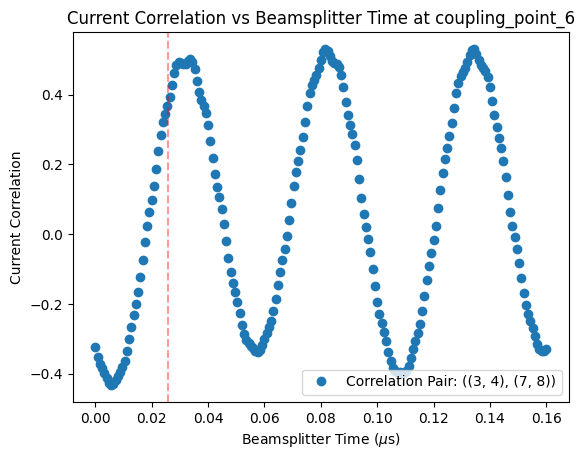

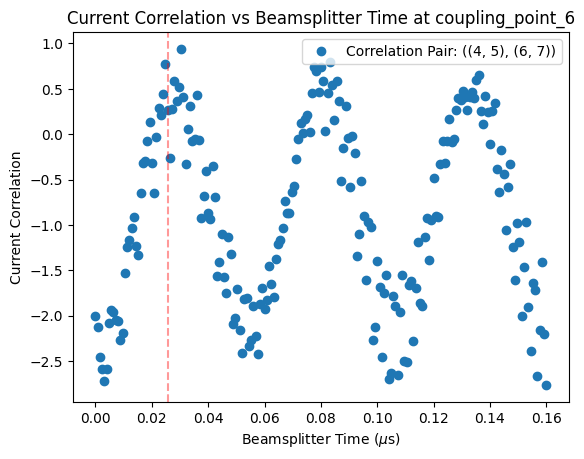

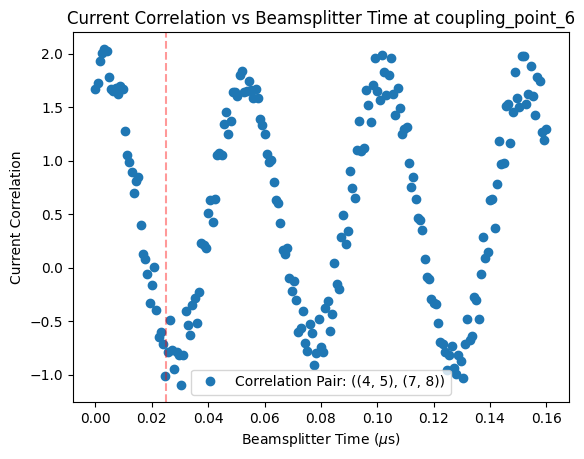

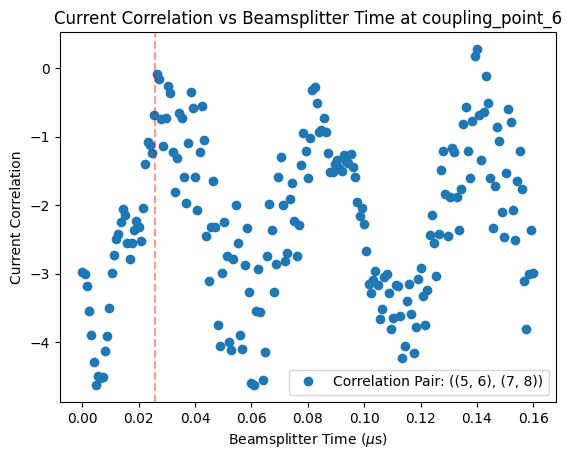

In [23]:
for correlation_pair in correlation_pairs:

    current_correlation = correlation_pair_to_current_correlation[correlation_pair]

    beamsplitter_time_simulation = correlation_pair_to_beamsplitter_time[correlation_pair]

    plt.plot(times, current_correlation, linestyle='', marker='o', label=f'Correlation Pair: {correlation_pair}')
    plt.xlabel('Beamsplitter Time ($\mu$s)')
    plt.ylabel('Current Correlation')
    plt.title(f'Current Correlation vs Beamsplitter Time at {coupling_point}')

    # plt.ylim(-0.4, 0.4)

    plt.axvline(beamsplitter_time_simulation, color='r', alpha=0.4, linestyle='--')

    plt.legend()
    plt.show()
    

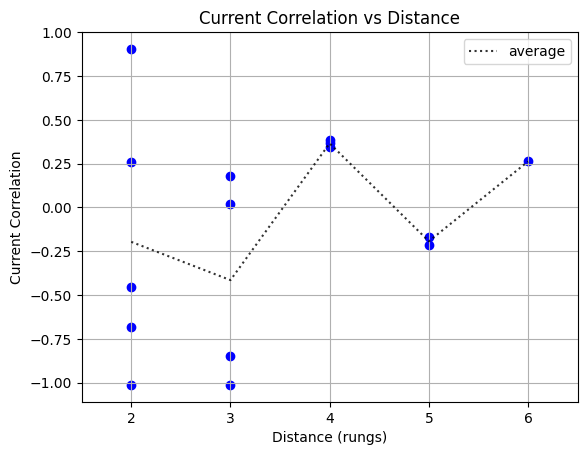

In [24]:
current_correlation_by_distance = {}


for correlation_pair in correlation_pairs:

    current_correlation_value = correlation_pair_to_current_correlation_value[correlation_pair]

    distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))

    if not distance in current_correlation_by_distance:
        current_correlation_by_distance[distance] = []
    
    current_correlation_by_distance[distance].append(current_correlation_value)


distances = []
current_correlation_averages = []

for distance in current_correlation_by_distance:
    distances.append(distance)
    current_correlation_averages.append(np.mean(current_correlation_by_distance[distance]))

# plot
for distance in current_correlation_by_distance:
    plt.scatter([distance]*len(current_correlation_by_distance[distance]), current_correlation_by_distance[distance], color='b')

plt.plot(distances, current_correlation_averages, linestyle=':', color='black', alpha=0.8, label='average')

plt.xlabel('Distance (rungs)')
plt.xticks([2, 3, 4, 5, 6])


plt.ylabel('Current Correlation')

plt.legend()

plt.grid()
plt.xlim(1.5, 6.5)

plt.title('Current Correlation vs Distance')



plt.show()

In [25]:
current_correlation_total = sum(current_correlation_averages)
print(current_correlation_total)

-0.175335142519441


In [26]:
data_dictionary = {}

for correlation_pair in correlation_pairs:

    data_dictionary[correlation_pair] = {}


    data_dictionary[correlation_pair]['beamsplitter_time'] = correlation_pair_to_beamsplitter_time[correlation_pair]

    data_dictionary[correlation_pair]['current_correlation_BS'] = correlation_pair_to_current_correlation[correlation_pair]
    data_dictionary[correlation_pair]['current_correlation_BS_value'] = correlation_pair_to_current_correlation_value[correlation_pair]

data_dictionary['current_correlation_BS_averages'] = current_correlation_averages
data_dictionary['distances'] = distances
data_dictionary['current_correlation_BS_total'] = current_correlation_total


In [27]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)


def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

In [28]:
# data_filename = 'current_correlations_data.h5'

# this overwrits the whole file !!! be careful
# save_nested_dict_to_hdf5(data_filename, {coupling_point: data_dictionary})


# this line keeps only the data at the specified location
# data = load_nested_dict_from_hdf5(data_filename)
# save_nested_dict_to_hdf5(data_filename, {'data': data['data']})


In [29]:
# data_filename = 'current_correlations_data.h5'

# keys = ('simulation', 'highest', dephasing, coupling_point)

# update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)


# 2. Exact Operator Measurement

In [30]:
current_simulation = CurrentSimulation(num_levels, num_qubits, num_particles, J_parallel, J, 0, U)
# current_simulation = CurrentSimulation(2, num_qubits, num_particles, J_parallel, J, 0, U)
# current_simulation = CurrentSimulation(2, num_qubits, num_particles, J_parallel, J, 0, 0)


In [31]:
# create fock state out of psi0

basis_4Q_fock = [FockBasisState(state) for state in basis_4Q]

# basis_fock = [FockBasisState(state) for state in basis]

if psi0_state.isket:
    psi0_fock = QuantumState(psi0_state.full()[:,0], basis_4Q_fock)
elif psi0_state.isoper:
    psi0_fock_basis = []
    psi0_fock_state = []

    trace_sum = 0

    for i in range(len(basis_4Q)):
        for j in range(len(basis_4Q)):
            coeff = psi0_state.full()[i,j]
            if abs(coeff) > 1e-10:
                psi0_fock_basis.append(FockBasisOuter(basis_4Q[i], basis_4Q[j]))
                psi0_fock_state.append(coeff)

        trace_sum += psi0_state.full()[i,i]

    psi0_fock = DensityMatrix(np.array(psi0_fock_state), psi0_fock_basis)




In [32]:
# # maximally mixed state test

# psi0_fock_state = []
# psi0_fock_basis = []

# trace_sum = 0
# for i in range(len(basis_4Q)):
#     psi0_fock_basis.append(FockBasisOuter(basis_4Q[i], basis_4Q[i]))
#     psi0_fock_state.append(1/len(basis_4Q))/

# psi0_fock_state = np.array(psi0_fock_state)

# psi0_fock = DensityMatrix(np.array(psi0_fock_state), psi0_fock_basis)



In [33]:
# print(psi0_fock.trace())
# print(psi0_fock.purity())


In [34]:
current_simulation.psi0 = psi0_fock
current_correlations_from_operator = current_simulation.get_current_correlations(only_rungs=True)
print(current_correlations_from_operator)


{((1, 2), (3, 4)): 4.520314015560179, ((1, 2), (4, 5)): 2.633101578787395, ((1, 2), (5, 6)): 0.9610042658220018, ((1, 2), (6, 7)): 0.46312052591299646, ((1, 2), (7, 8)): 0.3720150324633935, ((2, 3), (4, 5)): 3.9260875703950116, ((2, 3), (5, 6)): 1.7584493554714857, ((2, 3), (6, 7)): 0.8486528024001244, ((2, 3), (7, 8)): 0.3915166854056997, ((3, 4), (1, 2)): 4.520314015560179, ((3, 4), (5, 6)): 2.5098117089508314, ((3, 4), (6, 7)): 1.5722665792446548, ((3, 4), (7, 8)): 0.9453511650235482, ((4, 5), (1, 2)): 2.633101578787395, ((4, 5), (2, 3)): 3.9260875703950116, ((4, 5), (6, 7)): 3.645925309989222, ((4, 5), (7, 8)): 2.600303873927847, ((5, 6), (1, 2)): 0.9610042658220025, ((5, 6), (2, 3)): 1.7584493554714857, ((5, 6), (3, 4)): 2.5098117089508314, ((5, 6), (7, 8)): 4.527900723371056, ((6, 7), (1, 2)): 0.46312052591299646, ((6, 7), (2, 3)): 0.8486528024001242, ((6, 7), (3, 4)): 1.5722665792446553, ((6, 7), (4, 5)): 3.64592530998922, ((7, 8), (1, 2)): 0.3720150324633935, ((7, 8), (2, 3)): 

In [35]:
# remove pairs that share a vertex, and redefine signs (1,2),(4,5) is positive in pi flux

current_correlations_from_operator_normalized = {}

for correlation_pair in correlation_pairs:
    pair_1, pair_2 = correlation_pair

    multiplier = 1
    if abs(min(pair_1) - min(pair_2)) % 2 == 1:
        multiplier = -1

    current_correlations_from_operator_normalized[correlation_pair] = current_correlations_from_operator[correlation_pair]
    current_correlations_from_operator_normalized[correlation_pair] *= multiplier


current correlation total operator: 2.5480100233480183


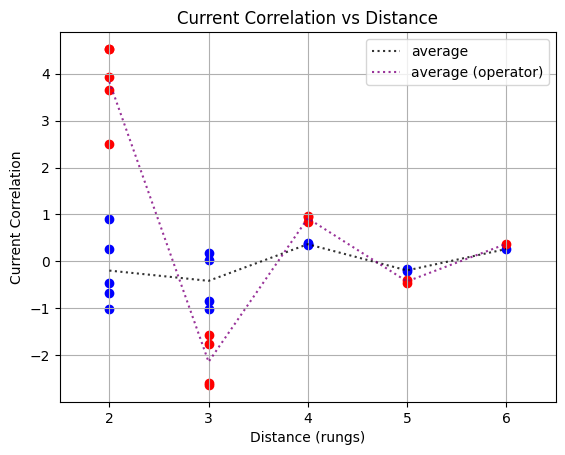

In [36]:
current_correlation_by_distance_operator = {}


for correlation_pair in correlation_pairs:

    current_correlation_value = current_correlations_from_operator_normalized[correlation_pair]

    distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))

    if not distance in current_correlation_by_distance_operator:
        current_correlation_by_distance_operator[distance] = []
    
    current_correlation_by_distance_operator[distance].append(current_correlation_value)


distances = []
current_correlation_averages = []
current_correlation_averages_operator = []

for distance in current_correlation_by_distance_operator:
    distances.append(distance)
    current_correlation_averages.append(np.mean(current_correlation_by_distance[distance]))
    current_correlation_averages_operator.append(np.mean(current_correlation_by_distance_operator[distance]))


current_correlation_total_operator = sum(current_correlation_averages_operator)
print(f'current correlation total operator: {current_correlation_total_operator}')

# plot
for distance in current_correlation_by_distance:
    plt.scatter([distance]*len(current_correlation_by_distance[distance]), current_correlation_by_distance[distance], color='b')
    plt.scatter([distance]*len(current_correlation_by_distance_operator[distance]), current_correlation_by_distance_operator[distance], color='r')

plt.plot(distances, current_correlation_averages, linestyle=':', color='black', alpha=0.8, label='average')
plt.plot(distances, current_correlation_averages_operator, linestyle=':', color='purple', alpha=0.8, label='average (operator)')

plt.xlabel('Distance (rungs)')
plt.xticks([2, 3, 4, 5, 6])

plt.legend()


plt.ylabel('Current Correlation')

plt.legend()

plt.grid()

plt.xlim(1.5, 6.5)
# plt.ylim(0, 0.5)
# plt.ylim(-0.2, 0.2)

plt.title('Current Correlation vs Distance')



plt.show()

In [37]:
# data_dictionary = {}

# for correlation_pair in correlation_pairs:

#     data_dictionary[correlation_pair] = {}


#     data_dictionary[correlation_pair]['current_correlation_value'] = current_correlations_from_operator_normalized[correlation_pair]

# data_dictionary['current_correlation_averages'] = current_correlation_averages_operator
# data_dictionary['current_correlation_total'] = current_correlation_total_operator

In [38]:
# we need to create the full data dictionary because it doesn't update nested items


data_dictionary = {}

for correlation_pair in correlation_pairs:

    data_dictionary[correlation_pair] = {}


    data_dictionary[correlation_pair]['beamsplitter_time'] = correlation_pair_to_beamsplitter_time[correlation_pair]

    data_dictionary[correlation_pair]['current_correlation_BS'] = correlation_pair_to_current_correlation[correlation_pair]
    data_dictionary[correlation_pair]['current_correlation_BS_value'] = correlation_pair_to_current_correlation_value[correlation_pair]

    data_dictionary[correlation_pair]['current_correlation_value'] = current_correlations_from_operator_normalized[correlation_pair]

data_dictionary['distances'] = distances

data_dictionary['current_correlation_BS_averages'] = current_correlation_averages
data_dictionary['distance_to_current_correlation_value_BS'] = current_correlation_by_distance
data_dictionary['current_correlation_BS_total'] = current_correlation_total

data_dictionary['current_correlation_averages'] = current_correlation_averages_operator
data_dictionary['distance_to_current_correlation_value'] = current_correlation_by_distance_operator
data_dictionary['current_correlation_total'] = current_correlation_total_operator


data_dictionary['times'] = times


In [39]:
data_filename = 'current_correlations_data.h5'

keys = ('simulation', eigenstate, str(dephasing), coupling_point)

# delete = False
# if delete:
#     data = load_nested_dict_from_hdf5(data_filename)
#     new_data = data.copy()

#     copied_data = data['simulation'][eigenstate]['no_dephasing'].copy()


#     new_data['simulation'][eigenstate] = {}

#     new_data['simulation'][eigenstate]['no_dephasing'] = copied_data

#     print(new_data['simulation'][eigenstate].keys())

#     update_data_file(data_filename, new_data['simulation'], keys=('simulation',), save_backup=True)


update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)


In [40]:
print(load_nested_dict_from_hdf5(data_filename)['simulation'][eigenstate].keys())

dict_keys(['0.01', '0.1', '0.2', '0.3', '0.5', '0.8', '1.0', '10.0', '2.0', '5.0', '50.0', 'no_dephasing', 'no_dephasing_ramp', 'real'])


In [41]:
# data_dict_from_file = load_nested_dict_from_hdf5(data_filename)

# print(data_dict_from_file.keys())
# print(data_dict_from_file['simulation'].keys())
# print(data_dict_from_file['simulation']['highest'].keys())
# print(data_dict_from_file['simulation']['highest']['no_dephasing'].keys())
# print(data_dict_from_file['simulation']['highest']['no_dephasing']['coupling_point_2'].keys())
# print(data_dict_from_file['simulation']['highest']['no_dephasing']['coupling_point_2']['((1, 2), (3, 4))'].keys())

# print()
# print(data_dictionary.keys())
# print(data_dictionary['((1, 2), (3, 4))'].keys())


# 3. Testing

In [ ]:






# analyze psi0 state occupcations


rho_reduced_truncated = convert_particle_sector_to_reduced_density_matrix(psi0_state, 
                                                  basis_4Q, 
                                                  (1,2) + (3,4), 
                                                  num_qubits=num_qubits,
                                                  num_levels=num_levels)



In [601]:
basis_reduced = list(product(range(num_levels), repeat=4))
basis_reduced_truncated = [state for state in basis_reduced if sum(state) <= 4]


# two_particle_space_sum = 0
# for i in range(len(basis_reduced_truncated)):
#     state = basis_reduced_truncated[i]
#     if not sum(state) <= 2:
#         continue
#     print(f'{state}\t\t{np.round(rho_reduced_truncated[i,i].real,3)}')

#     if sum(state) == 2:
#         two_particle_space_sum += rho_reduced_truncated[i,i].real

# print(f'population in 2-particle subspace: {two_particle_space_sum}')


rho_populations = [rho_reduced_truncated[i,i].real for i in range(len(basis_reduced_truncated))]

sorted_indices = np.argsort(rho_populations)

rho_populations_sorted = np.array(rho_populations)[sorted_indices][::-1]
basis_reduced_truncated_sorted = np.array(basis_reduced_truncated)[sorted_indices][::-1]

for i in range(len(basis_reduced_truncated)):
    state = basis_reduced_truncated_sorted[i]
    pop = rho_populations_sorted[i]
    print(f'{state}\t{np.round(pop,3)}')


[0 0 0 0]	0.073
[1 0 0 0]	0.062
[0 0 1 0]	0.061
[0 1 0 0]	0.061
[0 0 0 1]	0.061
[1 1 0 0]	0.039
[1 0 0 1]	0.039
[0 0 1 1]	0.039
[0 1 1 0]	0.039
[1 0 1 0]	0.038
[0 1 0 1]	0.037
[0 0 2 0]	0.031
[0 2 0 0]	0.031
[0 0 0 2]	0.031
[2 0 0 0]	0.03
[1 1 0 1]	0.017
[1 0 1 1]	0.017
[0 1 1 1]	0.017
[1 1 1 0]	0.017
[0 1 2 0]	0.014
[0 0 2 1]	0.014
[1 0 0 2]	0.014
[0 0 1 2]	0.014
[0 2 1 0]	0.014
[1 2 0 0]	0.014
[2 0 0 1]	0.014
[2 1 0 0]	0.014
[0 1 0 2]	0.013
[0 2 0 1]	0.013
[1 0 2 0]	0.013
[2 0 1 0]	0.013
[0 0 3 0]	0.006
[0 0 0 3]	0.006
[0 3 0 0]	0.005
[1 1 1 1]	0.004
[3 0 0 0]	0.004
[0 1 2 1]	0.004
[1 0 1 2]	0.004
[1 2 1 0]	0.003
[0 2 1 1]	0.003
[0 1 1 2]	0.003
[1 2 0 1]	0.003
[1 1 0 2]	0.003
[2 1 0 1]	0.003
[1 0 2 1]	0.003
[1 1 2 0]	0.003
[2 1 1 0]	0.003
[2 0 1 1]	0.003
[0 0 2 2]	0.003
[0 2 2 0]	0.003
[2 0 0 2]	0.003
[2 2 0 0]	0.003
[0 2 0 2]	0.002
[0 0 3 1]	0.001
[0 0 1 3]	0.001
[0 1 3 0]	0.001
[1 0 0 3]	0.001
[2 0 2 0]	0.001
[0 1 0 3]	0.001
[0 3 0 1]	0.001
[0 3 1 0]	0.001
[1 3 0 0]	0.001
[1 0 3 0]

In [602]:
rho_reduced_truncated

import pickle

# Save the ndarray to a pickle file
with open('rho_reduced_truncated.pkl', 'wb') as f:
    pickle.dump(rho_reduced_truncated, f)

# with open('rho_reduced_truncated.pkl', 'rb') as f:
#     rho_reduced_truncated = pickle.load(f)

In [603]:
### reduce psi0 state qubits to 2 qubits instead of 4


rho_reduced_truncated_2Q = convert_particle_sector_to_reduced_density_matrix(psi0_state, 
                                                  basis_4Q, 
                                                  (1,2), 
                                                  num_qubits=num_qubits,
                                                  num_levels=num_levels)

In [604]:
print(rho_reduced_truncated_2Q.dims)

[[15], [15]]


In [605]:
reduced_basis_2Q = list(product(range(num_levels), repeat=2))
reduced_basis_2Q_truncated = [state for state in reduced_basis_2Q if sum(state) <= 4]

print(len(reduced_basis_2Q_truncated))

15


In [606]:


rho_populations = [rho_reduced_truncated_2Q[i,i].real for i in range(len(reduced_basis_2Q_truncated))]

sorted_indices = np.argsort(rho_populations)

rho_populations_sorted = np.array(rho_populations)[sorted_indices][::-1]
basis_reduced_truncated_sorted = np.array(reduced_basis_2Q_truncated)[sorted_indices][::-1]

for i in range(len(basis_reduced_truncated_sorted)):
    state = basis_reduced_truncated_sorted[i]
    pop = rho_populations_sorted[i]
    print(f'{state}\t{np.round(pop,3)}')

[0 0]	0.342
[1 0]	0.192
[0 1]	0.191
[1 1]	0.084
[0 2]	0.066
[2 0]	0.065
[1 2]	0.021
[2 1]	0.02
[0 3]	0.008
[3 0]	0.006
[2 2]	0.003
[1 3]	0.001
[3 1]	0.001
[0 4]	0.0
[4 0]	0.0


In [607]:
### let's analyze the expectation values of <a_i^\dagger a_j> on the eigenstate

psi0_state

len(psi0_fock.state)
psi0_fock.basis

### look at first placquette with qubits 1,2,3

# define coherence_ij = <a_i^\dagger a_j> for i,j in (1,2), (2,3), (3,1)

# 12
new_state = psi0_fock.apply_raising_operator(0, num_levels).apply_lowering_operator(1)
coherence_12 = psi0_fock.inner_product(new_state)

# 23
new_state = psi0_fock.apply_raising_operator(1, num_levels).apply_lowering_operator(2)
coherence_23 = psi0_fock.inner_product(new_state)

# 31
new_state = psi0_fock.apply_raising_operator(2, num_levels).apply_lowering_operator(0)
coherence_31 = psi0_fock.inner_product(new_state)

# print(f'J: {J}')
# print(f'J_parallel: {J_parallel}')

print(f'<a_1^\\dagger a_2>: {coherence_12}')
print(f'<a_2^\\dagger a_3>: {coherence_23}')
print(f'<a_3^\\dagger a_1>: {coherence_31}')

# calculate complex arguments
arg_12 = np.angle(coherence_12)
arg_23 = np.angle(coherence_23)
arg_31 = np.angle(coherence_31)

print(f'arg_12: {arg_12}')
print(f'arg_23: {arg_23}')
print(f'arg_31: {arg_31}')


print()
# 18
new_state = psi0_fock.apply_raising_operator(0, num_levels).apply_lowering_operator(7)
coherence_18 = psi0_fock.inner_product(new_state)
print(f'<a_1^\\dagger a_8>: {coherence_18}')


AttributeError: 'DensityMatrix' object has no attribute 'inner_product'